In [17]:
protein_names = ["BPTI", "BRD4", "HOIP", "LXR", "MBP"]

import os 

import MDAnalysis as mda
import numpy as np
import json

import sys
sys.path.append("/home/alexi/Documents/ValDX/")

from ValDX.VDX_dataclasses import Segments
from ValDX.helpful_funcs import segs_to_df, segs_to_file, dfracs_to_df, HDX_to_file



In [18]:
BPTI_top_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/P00974_60_1_af_sample_127_10000_protonated.pdb"
BPTI_traj_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/P00974_60_1_af_sample_127_10000_protonated.xtc"
BPTI_json_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_simulations/P00974_60_1_af_sample_127_10000_ranks.json"
BPTI_segs_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_expt_data/BPTI_residue_segs.txt"
BPTI_hdx_path = "/home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_expt_data/BPTI_expt_dfracs_clean.dat"
BPTI_num_residues = 58
BPTI_times = [0.167, 1, 10]

BRD4_top_path = "/home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_484_1_af_sample_127_10000_protonated.pdb"
BRD4_traj_path = "/home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_484_1_af_sample_127_10000_protonated.xtc"
BRD4_json_path = "/home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_484_1_af_sample_127_10000_ranks.json"
BRD4_segs_path = "/home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_segs.txt"
BRD4_hdx_path = "/home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_clean.dat"
BRD4_num_residues = 484
BRD4_times = [0.25,	1.0,	10.0,	60.0]


HOIP_top_path = "/home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_apo697_1_af_sample_127_10000_protonated.pdb"
HOIP_traj_path = "/home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_apo697_1_af_sample_127_10000_protonated.xtc"
HOIP_json_path = "/home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_apo697_1_af_sample_127_10000_ranks.json"
HOIP_segs_path = "/home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_APO_segs.txt"
HOIP_hdx_path = "/home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_apo_clean.dat"
HOIP_num_residues = 376
HOIP_times = [0.5, 5.0]


LXR_top_path = "/home/alexi/Documents/ValDX/raw_data/LXRalpha/LXRalpha_APO/LXRa200_1_af_sample_127_10000_protonated.pdb"
LXR_traj_path = "/home/alexi/Documents/ValDX/raw_data/LXRalpha/LXRalpha_APO/LXRa200_1_af_sample_127_10000_protonated.xtc"
LXR_json_path = "/home/alexi/Documents/ValDX/raw_data/LXRalpha/LXRalpha_APO/LXRa200_1_af_sample_127_10000_ranks.json"
LXR_segs_path = "/home/alexi/Documents/ValDX/raw_data/LXRalpha/LXRalpha_APO/LXRa_APO_segs200.txt"
LXR_hdx_path = "/home/alexi/Documents/ValDX/raw_data/LXRalpha/LXRalpha_APO/LXRa_APO200.dat"

LXR_num_residues = 250
LXR_times = [0.5, 5.0]

MBP_top_path = "/home/alexi/Documents/ValDX/raw_data/MBP/MBP_wt_1_af_sample_127_10000_protonated.pdb"
MBP_traj_path = "/home/alexi/Documents/ValDX/raw_data/MBP/MBP_wt_1_af_sample_127_10000_protonated.xtc" 
MBP_json_path = "/home/alexi/Documents/ValDX/raw_data/MBP/MBP_wt_1_af_sample_127_10000_ranks.json"
MBP_segs_path = "/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_wt1_segs.txt"
MBP_hdx_path = "/home/alexi/Documents/ValDX/raw_data/MBP/MaltoseBindingProtein/MBP_wt1_clean.dat"
MBP_num_residues = 396
MBP_times = [0.5,	4.0,	30.0]





proteins = {"BPTI": {"top": BPTI_top_path, "traj": BPTI_traj_path, "json": BPTI_json_path, "num_residues": BPTI_num_residues, "segs_path":BPTI_segs_path, "times": BPTI_times, "hdx_path": BPTI_hdx_path},
            "BRD4": {"top": BRD4_top_path, "traj": BRD4_traj_path, "json": BRD4_json_path, "num_residues": BRD4_num_residues, "segs_path":BRD4_segs_path, "times": BRD4_times, "hdx_path": BRD4_hdx_path},
            "HOIP": {"top": HOIP_top_path, "traj": HOIP_traj_path, "json": HOIP_json_path, "num_residues": HOIP_num_residues, "segs_path":HOIP_segs_path, "times": HOIP_times, "hdx_path": HOIP_hdx_path},
            "LXR": {"top": LXR_top_path, "traj": LXR_traj_path, "json": LXR_json_path, "num_residues": LXR_num_residues, "segs_path":LXR_segs_path, "times": LXR_times, "hdx_path": LXR_hdx_path},
            "MBP": {"top": MBP_top_path, "traj": MBP_traj_path, "json": MBP_json_path, "num_residues": MBP_num_residues, "segs_path":MBP_segs_path, "times": MBP_times, "hdx_path": MBP_hdx_path}}



def load_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data


json_data = {protein: load_json(proteins[protein]["json"]) for protein in protein_names}


from typing import Dict

def extract_val_json(protein_data: Dict, key: str="plddt")->np.array:

    val_data = []
    for msa, run in protein_data.items():
        for rank, data in run.items():
            if key in data:
                val_data.append(data[key])

    return np.array(val_data)

plddt_data = {protein: extract_val_json(json_data[protein]) for protein in protein_names}

max_pae_data = {protein: extract_val_json(json_data[protein], key='max_pae') for protein in protein_names}

ptm_data = {protein: extract_val_json(json_data[protein], key='ptm') for protein in protein_names}

time_data = {protein: proteins[protein]["times"] for protein in protein_names}

hdx_data = {protein: dfracs_to_df(path=proteins[protein]["hdx_path"],names=time_data[protein]) for protein in protein_names}


Path /home/alexi/Documents/ValDX/raw_data/HDXer_tutorial/BPTI/BPTI_expt_data/BPTI_expt_dfracs_clean.dat
RW: ncol = 3, len(names) = 3
(41, 4)
     0.167      1.0     10.0  peptide
0  0.15669  0.63957  0.99996        0
1  0.09039  0.43293  0.99656        1
2  0.02665  0.14933  0.80157        2
3  0.18680  0.71010  1.00000        3
4  0.99880  1.00000  1.00000        4
Path /home/alexi/Documents/ValDX/raw_data/BRD4/BRD4_APO/BRD4_APO_clean.dat
RW: ncol = 4, len(names) = 4
(103, 5)
      0.25      1.0     10.0     60.0  peptide
0  1.00000  1.00000  0.93472  0.89664        0
1  1.00000  1.00000  0.99807  0.95428        1
2  0.93736  0.96691  0.92883  0.95483        2
3  1.00000  1.00000  1.00000  1.00000        3
4  0.85449  0.94087  0.89530  0.88101        4
Path /home/alexi/Documents/ValDX/raw_data/HOIP/HOIP_apo/HOIP_apo_clean.dat
RW: ncol = 2, len(names) = 2
(108, 3)
       0.5      5.0  peptide
0  0.41879  0.44438        0
1  0.37096  0.45204        1
2  0.40040  0.48544        2
3  0.45

In [5]:

# import sys
# sys.path.append("/home/alexi/Documents/ValDX/")
from ValDX.VDX_dataclasses import Segments

segs_data = {protein:Segments(segs_path=proteins[protein]["segs_path"]) for protein in proteins}


res_data = {protein:segs_data[protein].residues for protein in proteins}
print(res_data)

/home/alexi/Documents/ValDX


/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/Bio/Application/__init__.py:40: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Segments class created with 41 peptides
Resnumbers calculated for 41 segments
Resnumbers calculated for 41 segments
Residues calculated for 50 segments
Resnumbers calculated for 41 segments
Peptides calculated for 41 segments
Calculating residue centrality
Resnumbers calculated for 41 segments
Calculating peptide centrality
Resnumbers calculated for 41 segments
Peptides calculated for 41 segments
Calculating residue centrality
Resnumbers calculated for 41 segments
Peptide centrality calculated for 41 peptides
Segments class created with 94 peptides
Resnumbers calculated for 94 segments
Resnumbers calculated for 94 segments
Residues calculated for 222 segments
Resnumbers calculated for 94 segments
Peptides calculated for 94 segments
Calculating residue centrality
Resnumbers calculated for 94 segments
Calculating peptide centrality
Resnumbers calculated for 94 segments
Peptides calculated for 94 segments
Calculating residue centrality
Resnumbers calculated for 94 segments
Peptide central

/tmp/ipykernel_1676043/3793529599.py:14: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1676043/3793529599.py:14: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1676043/3793529599.py:14: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


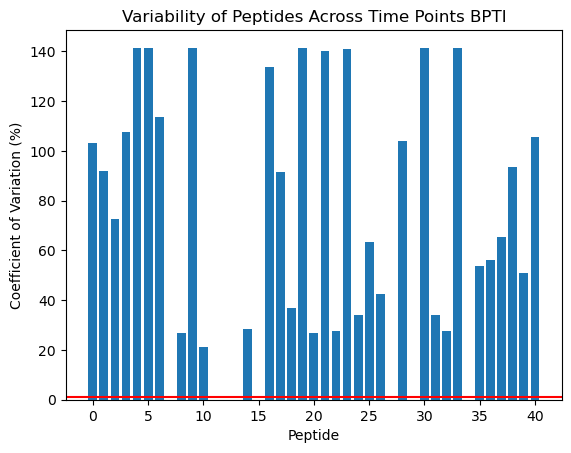

0.0
7 7
1.0 1.0
0.0
15 15
1.0 1.0
0.0
27 27
1.0 1.0
0.0
29 29
1.0 1.0
0.0
34 34
1.0 1.0


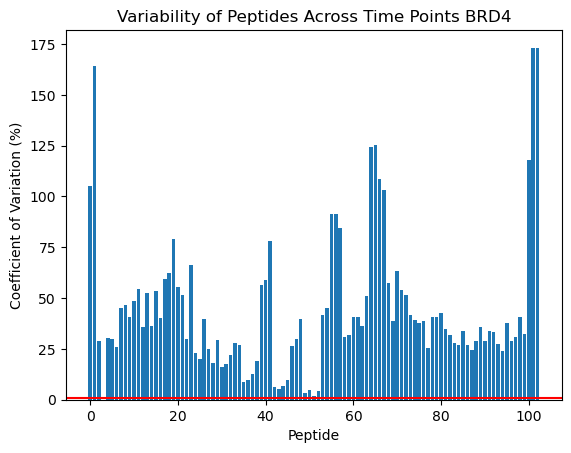

0.0
3 3
1.0 1.0


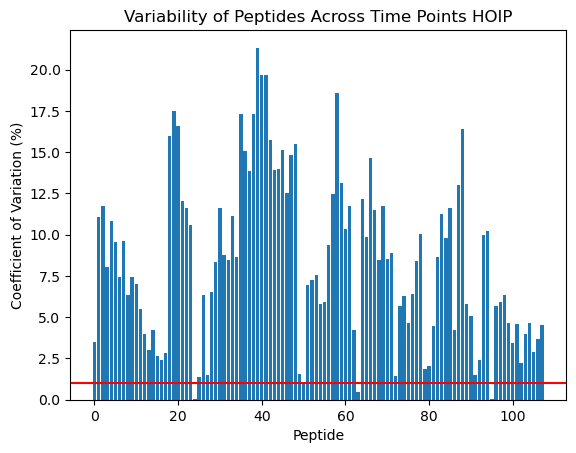

0.017677984638131992
24 24
0.35604 0.35617
0.48948725117335007
63 63
0.535 0.53827
0.04755580224870329
95 95
0.04358 0.04371


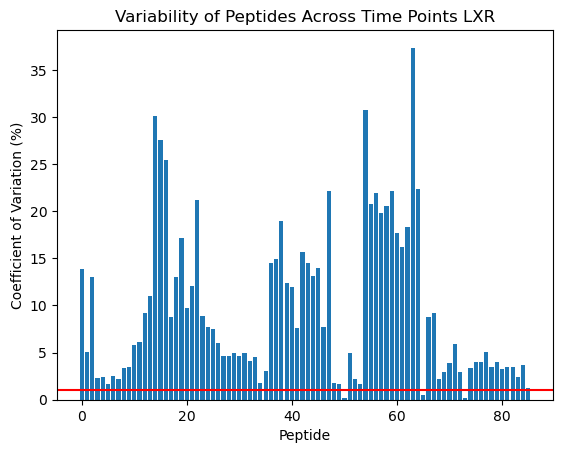

0.23240256581516516
50 50
0.40737 0.40907
0.5106198627441753
65 65
0.25632 0.25989
0.23413803122537877
73 73
0.32328 0.32499


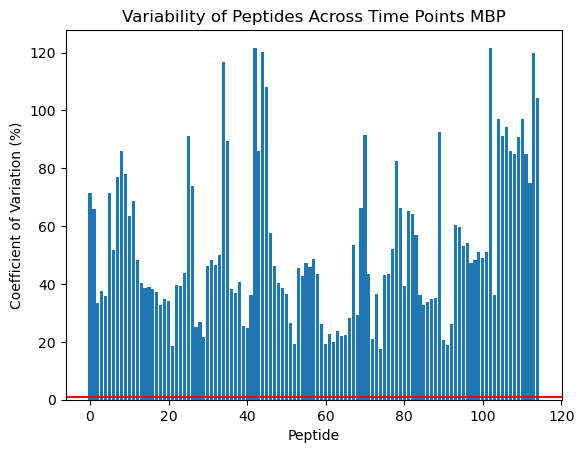

In [65]:

for protein in protein_names:

    segs = segs_data[protein]
    
    hdx_df_stats = hdx_data[protein]
    # print(hdx_df_stats)
    all_segs_df = segs.segs_df
    # print(all_segs_df)
    times = proteins[protein]["times"]

    # times = np.array(times).astype(str)
    # Calculate the coefficient of variation for each peptide
    for idx, row in hdx_df_stats.iterrows():
        peptide_values = np.abs(-1*np.log(row[times].values))
        mean_value = np.mean(peptide_values)
        std_value = np.std(peptide_values)
        if std_value != 0:
            cv = std_value / mean_value * 100
            hdx_df_stats.loc[idx, 'cv'] = cv
        else:
            hdx_df_stats.loc[idx, 'cv'] = 0
    
    # print(hdx_df_stats)

    # Plot the coefficient of variation of each peptide
    import matplotlib.pyplot as plt

    plt.bar(hdx_df_stats.peptide, hdx_df_stats['cv'])
    plt.axhline(y=1, color='r', linestyle='-')  # Add a reference line at CV=30%
    plt.xlabel('Peptide')
    plt.ylabel('Coefficient of Variation (%)')
    plt.title(f'Variability of Peptides Across Time Points {protein}')
    # plt.yscale('log')
    plt.show()

    # Print peptides with CV < 5%
    for idx, peptide in enumerate(hdx_df_stats.peptide):
        if np.round(hdx_df_stats.loc[idx, 'cv'],1) <= 1:
            print(hdx_df_stats.loc[idx, 'cv'])
            # print(all_segs_df[all_segs_df['peptide'] == peptide])
            print(idx, peptide)
            min_hdx = hdx_df_stats.loc[idx, times].min()
            max_hdx = hdx_df_stats.loc[idx, times].max()
            print(min_hdx, max_hdx)



In [66]:
import MDAnalysis as mda

for protein in protein_names:
    segs = segs_data[protein]
    hdx_df_stats = hdx_data[protein]
    all_segs_df = segs.segs_df
    times = proteins[protein]["times"]

    # Calculate the coefficient of variation for each peptide
    for idx, row in hdx_df_stats.iterrows():
        peptide_values = np.abs(-1*np.log(row[times].values))
        mean_value = np.mean(peptide_values)
        std_value = np.std(peptide_values)
        if std_value != 0:
            cv = std_value / mean_value * 100
            hdx_df_stats.loc[idx, 'cv'] = cv
        else:
            hdx_df_stats.loc[idx, 'cv'] = 0
    

    # Calculate the average CV values for each residue
    residue_cv = {res: [] for res in segs.residues}
    for idx, peptide in enumerate(all_segs_df.peptide):
        cv = hdx_df_stats.loc[idx, 'cv']
        for res in segs.peptides[peptide]:
            residue_cv[res].append(cv)

    # invert so that small variance get higher bfactors
    cv_threshold = 1

    for res in residue_cv:
        res_avg = np.min(residue_cv[res])
        res_avg = np.round(res_avg, 1)
        if res_avg != 0:
            # res_avg = 0.1
            if res_avg <= cv_threshold:
                res_avg = 100/res_avg
            else:
                res_avg = 0

            if res_avg > 100/cv_threshold:
                res_avg = 100
        else:
            res_avg = 200

        residue_cv[res] = res_avg





    # Create a copy of the topology file and add the average CV values as B-factors
    u = mda.Universe(proteins[protein]["top"], proteins[protein]["traj"])
    u_copy = mda.Universe(proteins[protein]["top"])
    
    for res in u_copy.residues:
        res_num = res.resnum
        if res_num in residue_cv:
            for atom in res.atoms:
                atom.tempfactor = residue_cv[res_num]
        # else:
        #     for atom in res.atoms:
        #         atom.tempfactor = 0.0

    # Save the modified topology file
    output_top = f"{protein}_cv_bfactors.pdb"
    output_path = os.getcwd()
    output_path = os.path.join(output_path, output_top)
    u_copy.atoms.write(output_path)

/tmp/ipykernel_1676043/2995379455.py:11: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1676043/2995379455.py:11: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1676043/2995379455.py:11: RuntimeWarning: divide by zero encountered in log
  peptide_values = np.abs(-1*np.log(row[times].values))
/home/alexi/anaconda3/envs/HDXER_ENV/lib/python3.8/site-packages/numpy/core/_methods.py:236: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/alexi/anaconda3/

In [ ]:
BPTI_trim_peptides = [7,15,27,29,34]
BRD4_trim_peptides = [] # these are removed in seperate BRD4 HDX by domain script
HOIP_trim_peptides = [24,63,95]
LXR_trim_peptides = [50,65,73]
MBP_trim_peptides = [] # no peptides were identified as having low variance


# we will just remove these manually 